# Самостоятельная работа №3
**Простая линейная регрессия**

In [1]:
from utils.Reader import Reader
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import t
from prettytable import PrettyTable

In [2]:
file = Reader("./variant_8_data.csv")

X = np.array(file.read_column(1, sep=","))
Y = np.array(file.read_column(2, sep=","))

## Построение диаграммы рассеяния 

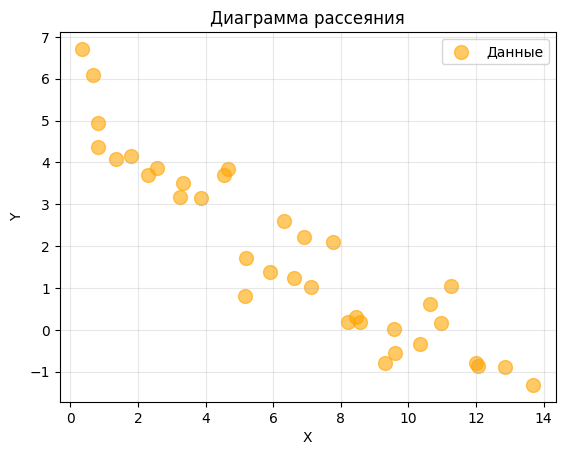

In [3]:
plt.scatter(X, Y, alpha=0.6, s=100, label='Данные', color='orange')
plt.xlabel("X")
plt.ylabel("Y")
plt.title("Диаграмма рассеяния")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Данные больше всего похожи на обратную линейную зависимость

# Оценивание коэффициентов регрессии

Выборочные средние:
$$
 \overline{x} = \frac{1}{n} \sum_{i=1}^{n} x_i \quad \quad
 \overline{y} = \frac{1}{n} \sum_{i=1}^{n} y_i
$$

Вспомогательные суммы:
$$
 S_{x x} = \sum_{i=1}^{n} (x_i - \overline{x})^2 \quad \quad
 S_{x y} = \sum_{i=1}^{n} (x_i - \overline{x})(y_i - \overline{y}) \\
$$

Оценки коэффициентов регрессии
$$
 \hat{\beta}_1 = \frac{S_{x y}}{S_{x x}} \quad \quad
 \hat{\beta}_0 = \overline{y} - \hat{\beta}_1 \overline{x} \\

 \hat{y} = \hat{\beta}_0 + \hat{\beta}_1 \cdot x
$$

In [4]:
n = len(X)

x_mean = np.mean(X)
y_mean = np.mean(Y)

S_xx = np.sum((X - x_mean) ** 2)
S_xy = np.sum((X - x_mean) * (Y - y_mean))

beta_1 = S_xy / S_xx
beta_0 = y_mean - beta_1 * x_mean

print(f"beta_0 = {beta_0}")
print(f"beta_1 = {beta_1}")
print(f"y = {beta_0:.3f} + ({beta_1:.3f}) * x")

beta_0 = 5.206679419703401
beta_1 = -0.510190829438456
y = 5.207 + (-0.510) * x


# Расчёт прогнозных значений и остатков

In [5]:
Y_hat = beta_0 + beta_1 * X
errors = Y - Y_hat
errors_sq = errors ** 2

table = PrettyTable()

table.field_names = ["i", "X", "Y", "Y_hat", "e", "e^2"]

for i in range(n):
    table.add_row([
        i + 1,
        round(X[i], 4),
        round(Y[i], 4),
        round(Y_hat[i], 4),
        round(errors[i], 4),
        round(errors_sq[i], 4)
    ])

print(table)

+----+---------+---------+---------+---------+--------+
| i  |    X    |    Y    |  Y_hat  |    e    |  e^2   |
+----+---------+---------+---------+---------+--------+
| 1  |  0.3551 |  6.7109 |  5.0255 |  1.6854 | 2.8405 |
| 2  |  0.6637 |  6.0909 |  4.8681 |  1.2228 | 1.4953 |
| 3  |  0.8216 |  4.9496 |  4.7875 |  0.1621 | 0.0263 |
| 4  |  0.8328 |  4.3577 |  4.7818 | -0.4241 | 0.1799 |
| 5  |  1.3558 |  4.0933 |  4.515  | -0.4217 | 0.1778 |
| 6  |  1.787  |  4.1501 |  4.295  | -0.1449 | 0.021  |
| 7  |  2.2993 |  3.7045 |  4.0336 | -0.3291 | 0.1083 |
| 8  |  2.5524 |  3.8696 |  3.9045 | -0.0349 | 0.0012 |
| 9  |  3.2541 |  3.1661 |  3.5465 | -0.3804 | 0.1447 |
| 10 |  3.3253 |  3.512  |  3.5101 |  0.0019 |  0.0   |
| 11 |  3.8765 |  3.1567 |  3.2289 | -0.0722 | 0.0052 |
| 12 |  4.557  |  3.7017 |  2.8817 |   0.82  | 0.6723 |
| 13 |  4.6781 |  3.8473 |   2.82  |  1.0273 | 1.0554 |
| 14 |  5.1761 |  0.7969 |  2.5659 |  -1.769 | 3.1293 |
| 15 |  5.1939 |  1.7185 |  2.5568 | -0.8383 | 0

# Оценка дисперсии ошибки

Остаточная сумма квадратов:
$$
RSS = \sum_{i=1}^{n} e_i^2
$$
Несмещённая оценка дисперсии ошибки:
$$
s^2 = \frac{RSS}{n - 2}
$$
Остаточное стандартное отклонение:
$$
s = \sqrt{s^2}
$$


In [6]:
RSS = np.sum(errors_sq)

s2 = RSS / (n - 2)
s = np.sqrt(s2)

print(f"RSS = {RSS}")
print(f"s^2 = {s2}")
print(f"s = {s}")

RSS = 21.122885254497387
s^2 = 0.6400874319544663
s = 0.8000546431053733


# Доверительные интервалы для коэффициентов

Стандартная ошибка коэффициента:
Для $\beta_1$:
$$
SE(\beta_1) = \frac{s}{\sqrt{S_{xx}}}
$$

Для $\beta_0$:
$$
SE(\beta_0) =
s \sqrt{
\frac{1}{n} +
\frac{\overline{x}^2}{S_{xx}}
}
$$
Критическое значение распределения Стьюдента:
$$
t_{crit} = t_{1 - \alpha/2; \, n-2}
$$
Доверительный интервал:
$$
\beta_i \pm t_{crit} \cdot SE(\beta_i)
$$

In [7]:
alpha = 0.05

t_crit = t.ppf(1 - alpha / 2, df=n - 2)

SE_beta1 = s / np.sqrt(S_xx)

SE_beta0 = s * np.sqrt(
    1 / n + (x_mean ** 2) / S_xx
)

beta1_left = beta_1 - t_crit * SE_beta1
beta1_right = beta_1 + t_crit * SE_beta1

beta0_left = beta_0 - t_crit * SE_beta0
beta0_right = beta_0 + t_crit * SE_beta0

print("Доверительный интервал для beta_0:")
print(f"[{beta0_left}, {beta0_right}]")

print()

print("Доверительный интервал для beta_1:")
print(f"[{beta1_left}, {beta1_right}]")

# %%
if beta1_left <= 0 <= beta1_right:
    print("0 попадает в доверительный интервал beta_1")
    print("Линейная зависимость статистически НЕ значима")
else:
    print("0 не попадает в доверительный интервал beta_1")
    print("Линейная зависимость статистически значима")

Доверительный интервал для beta_0:
[4.666480694070094, 5.746878145336709]

Доверительный интервал для beta_1:
[-0.5812463019709283, -0.4391353569059836]
0 не попадает в доверительный интервал beta_1
Линейная зависимость статистически значима


# Коэффициент детерминации

Общая сумма квадратов:
$$
TSS = \sum_{i=1}^{n} (y_i - \overline{y})^2
$$
Коэффициент детерминации:
$$
R^2 = 1 - \frac{RSS}{TSS}
$$

In [8]:
TSS = np.sum((Y - y_mean) ** 2)

R2 = 1 - RSS / TSS

print(f"R^2 = {R2}")

R^2 = 0.8660708239898794


# Доверительный интервал для функции регрессии

Оценка функции регрессии:
 $$
 \hat{y}(x_0) = \hat{\beta}_0 + \hat{\beta}_1 x_0
 $$

 Стандартная ошибка:
 $$
 SE_{\hat{y}}(x_0) =
 s \sqrt{
 \frac{1}{n} +
 \frac{(x_0 - \overline{x})^2}{S_{xx}}
 }
 $$

 95% доверительный интервал:
 $$
 \hat{y}(x_0)
 \pm
 t_{crit} \cdot SE_{\hat{y}}(x_0)
 $$

In [ ]:
x_line = np.linspace(np.min(X), np.max(X), 200)

y_line = beta_0 + beta_1 * x_line

SE_y = s * np.sqrt(
    1 / n + ((x_line - x_mean) ** 2) / S_xx
)

lower = y_line - t_crit * SE_y
upper = y_line + t_crit * SE_y

# График регрессии с погрешностями

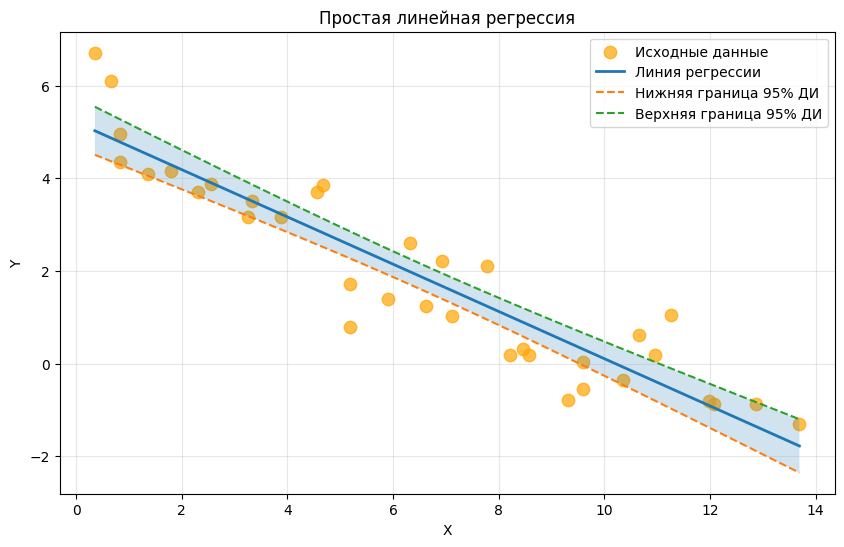

In [10]:
plt.figure(figsize=(10, 6))

# исходные точки
plt.scatter(
    X,
    Y,
    color='orange',
    s=80,
    alpha=0.7,
    label='Исходные данные'
)

# линия регрессии
plt.plot(
    x_line,
    y_line,
    linewidth=2,
    label='Линия регрессии'
)

# доверительный интервал
plt.plot(
    x_line,
    lower,
    linestyle='--',
    label='Нижняя граница 95% ДИ'
)

plt.plot(
    x_line,
    upper,
    linestyle='--',
    label='Верхняя граница 95% ДИ'
)

plt.fill_between(
    x_line,
    lower,
    upper,
    alpha=0.2
)

plt.xlabel("X")
plt.ylabel("Y")
plt.title("Простая линейная регрессия")

plt.grid(True, alpha=0.3)
plt.legend()

plt.show()

# Выводы
1. Получено уравнение линейной регрессии
2. Зависимость между X и Y отрицательная, так как $\beta_1 < 0$.
3. Если 0 не входит в доверительный интервал для $\beta_1$, то коэффициент значим.
4. Линейную зависимость можно считать статистически значимой при $\alpha = 0.05$.
5. Доверительный интервал наиболее узкий около среднего значения x.
6. Чем ближе $R^2$ к 1, тем лучше качество модели.